# 🗄️ Modelagem de Dados

`Banco de Dados` · **8º semestre · Engenharia da Computação** · `Python 3`

> **Modelo conceitual, relacional, cardinalidade, normalização e integridade.**

Da entidade ao banco: modelo conceitual, diagrama ER, cardinalidades, normalização (1FN/2FN/3FN) e criação do esquema físico com SQLite.


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF gerado abaixo).

### 🟢 MODELO CONCEITUAL & ENTIDADES

**Ideia:** Representar o domínio antes do banco, identificando entidades, atributos e regras do negócio.

- Entidade: objeto relevante do domínio
- Atributo: característica que descreve uma entidade
- Identificador: atributo(s) que distinguem ocorrências
- Entidade forte: possui identificador próprio
- Entidade fraca: depende de outra para identificação
- Atributo composto: pode ser decomposto em partes
- Multivalorado: pode assumir vários valores
- DER: visão gráfica do modelo conceitual

> 💡 **Dica:** Comece pelo negócio, não pelas tabelas. Se você entende entidades e regras, o modelo lógico fica muito mais simples.

### 🟢 RELAÇÕES & CARDINALIDADE

**Ideia:** Definir como entidades se conectam e quantas ocorrências podem participar de cada relação.

- 1:1: uma ocorrência relaciona-se com no máximo uma
- 1:N: uma ocorrência relaciona-se com várias da outra entidade
- N:N: várias de ambos os lados; vira entidade associativa
- Cardinalidade mínima: participação opcional (0) ou obrigatória (1)
- Cardinalidade máxima: 1 ou N
- Relacionamento: pode possuir atributos próprios
- Auto-relacionamento: entidade relaciona-se com ela mesma
- Regra: cardinalidade deve refletir o negócio real

> 💡 **Dica:** Leia a relação nos dois sentidos. Pergunte: “quantos A para cada B?” e depois “quantos B para cada A?”.

### 🟢 MODELO LÓGICO & NORMALIZAÇÃO

**Ideia:** Converter o modelo conceitual em tabelas consistentes, reduzindo redundância e anomalias.

- Relação: tabela; tupla: linha; atributo: coluna
- PK: identifica cada registro de forma única
- FK: implementa relacionamentos entre tabelas
- 1FN: valores atômicos, sem grupos repetitivos
- 2FN: 1FN + sem dependência parcial da chave
- 3FN: 2FN + sem dependência transitiva
- N:N: criar tabela associativa com FKs

> 💡 **Dica:** Normalizar não é “quebrar tabelas por quebrar”. O objetivo é eliminar dependências inadequadas sem perder significado.

### 🟢 MODELO FÍSICO, CHAVES & INTEGRIDADE

**Ideia:** Preparar o modelo para implementação no SGBD, definindo tipos, restrições e decisões de desempenho.

- Tipo de dado: escolher domínio adequado para cada atributo
- NOT NULL: impede ausência de valor
- UNIQUE: impede duplicidades em uma coluna/conjunto
- CHECK: aplica regra de domínio
- FK: mantém integridade referencial
- ON DELETE/UPDATE: definir RESTRICT, CASCADE, SET NULL etc.
- Índice: melhora leitura, mas aumenta custo de escrita
- Modelo físico: considera SGBD, volume, acesso e performance

> 💡 **Dica:** No físico, cada restrição deve ter motivo. Use integridade no banco para impedir dados inválidos, não apenas na aplicação.


## ⚙️ Gerador do Cheat Sheet (PDF)

O script original gera um **PDF estilo OneNote** com `reportlab`. Para rodar em qualquer sistema operacional, as fontes são resolvidas automaticamente (usa a **DejaVu embarcada no matplotlib** com fallback para os caminhos clássicos de Windows/Linux/macOS) e o arquivo de saída é gerado na pasta atual.


In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path
from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Modelagem_de_Dados.pdf')
PAGE_W,PAGE_H=landscape(A4); MARGIN=16
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond',str(FONT_DIR/'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold',str(FONT_DIR/'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique',str(FONT_DIR/'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily('DVCond',normal='DVCond',bold='DVCond-Bold',italic='DVCond-Oblique',boldItalic='DVCond-Bold')
BG=HexColor('#F6F8FB'); GRID=HexColor('#E6EBF3'); INK=HexColor('#1C2B4A'); MUTED=HexColor('#5A6B8C'); WHITE=HexColor('#FFFFFF'); LINE=HexColor('#E7ECF4'); AXIS=HexColor('#D7DEEA')
TEAL,TEAL_T=HexColor('#147D82'),HexColor('#E3F2F1'); AMBER,AMBER_T=HexColor('#C97A1A'),HexColor('#FBEDDD'); BERRY,BERRY_T=HexColor('#A83E63'),HexColor('#F6E4EB'); GREEN,GREEN_T=HexColor('#2F7A4F'),HexColor('#E2F0E7')
CARDS=[
{'title':'MODELO CONCEITUAL<br/>&amp; ENTIDADES','color':TEAL,'tint':TEAL_T,'kind':'conceitual','idea':'Representar o domínio antes do banco, identificando entidades, atributos e regras do negócio.','formulas':['<b>Entidade:</b> objeto relevante do domínio','<b>Atributo:</b> característica que descreve uma entidade','<b>Identificador:</b> atributo(s) que distinguem ocorrências','<b>Entidade forte:</b> possui identificador próprio','<b>Entidade fraca:</b> depende de outra para identificação','<b>Atributo composto:</b> pode ser decomposto em partes','<b>Multivalorado:</b> pode assumir vários valores','<b>DER:</b> visão gráfica do modelo conceitual'],'tip':'Comece pelo negócio, não pelas tabelas. Se você entende entidades e regras, o modelo lógico fica muito mais simples.'},
{'title':'RELAÇÕES &amp;<br/>CARDINALIDADE','color':AMBER,'tint':AMBER_T,'kind':'relacoes','idea':'Definir como entidades se conectam e quantas ocorrências podem participar de cada relação.','formulas':['<b>1:1:</b> uma ocorrência relaciona-se com no máximo uma','<b>1:N:</b> uma ocorrência relaciona-se com várias da outra entidade','<b>N:N:</b> várias de ambos os lados; vira entidade associativa','<b>Cardinalidade mínima:</b> participação opcional (0) ou obrigatória (1)','<b>Cardinalidade máxima:</b> 1 ou N','<b>Relacionamento:</b> pode possuir atributos próprios','<b>Auto-relacionamento:</b> entidade relaciona-se com ela mesma','<b>Regra:</b> cardinalidade deve refletir o negócio real'],'tip':'Leia a relação nos dois sentidos. Pergunte: “quantos A para cada B?” e depois “quantos B para cada A?”.'},
{'title':'MODELO LÓGICO<br/>&amp; NORMALIZAÇÃO','color':BERRY,'tint':BERRY_T,'kind':'logico','idea':'Converter o modelo conceitual em tabelas consistentes, reduzindo redundância e anomalias.','formulas':['<b>Relação:</b> tabela; <b>tupla:</b> linha; <b>atributo:</b> coluna','<b>PK:</b> identifica cada registro de forma única','<b>FK:</b> implementa relacionamentos entre tabelas','<b>1FN:</b> valores atômicos, sem grupos repetitivos','<b>2FN:</b> 1FN + sem dependência parcial da chave','<b>3FN:</b> 2FN + sem dependência transitiva','<b>N:N:</b> criar tabela associativa com FKs'],'tip':'Normalizar não é “quebrar tabelas por quebrar”. O objetivo é eliminar dependências inadequadas sem perder significado.'},
{'title':'MODELO FÍSICO,<br/>CHAVES &amp; INTEGRIDADE','color':GREEN,'tint':GREEN_T,'kind':'fisico','idea':'Preparar o modelo para implementação no SGBD, definindo tipos, restrições e decisões de desempenho.','formulas':['<b>Tipo de dado:</b> escolher domínio adequado para cada atributo','<b>NOT NULL:</b> impede ausência de valor','<b>UNIQUE:</b> impede duplicidades em uma coluna/conjunto','<b>CHECK:</b> aplica regra de domínio','<b>FK:</b> mantém integridade referencial','<b>ON DELETE/UPDATE:</b> definir RESTRICT, CASCADE, SET NULL etc.','<b>Índice:</b> melhora leitura, mas aumenta custo de escrita','<b>Modelo físico:</b> considera SGBD, volume, acesso e performance'],'tip':'No físico, cada restrição deve ter motivo. Use integridade no banco para impedir dados inválidos, não apenas na aplicação.'}
]
CARD_TOP=PAGE_H-16; CARD_BOTTOM=16; CARD_H=CARD_TOP-CARD_BOTTOM; GAP=14; CARD_W=(PAGE_W-2*MARGIN-3*GAP)/4
STYLE_TITLE=ParagraphStyle('card_title',fontName='DVCond-Bold',fontSize=17.2,leading=18.6,textColor=WHITE,alignment=1)
STYLE_IDEA=ParagraphStyle('idea',fontName='DVCond-Oblique',fontSize=12.6,leading=15.6,textColor=MUTED)
STYLE_TIP=ParagraphStyle('tip',fontName='DVCond',fontSize=11.7,leading=14.7,textColor=INK)

def arrow(c,x1,y1,x2,y2,color,width=1.2,head=5):
 c.setStrokeColor(color); c.setFillColor(color); c.setLineWidth(width); c.line(x1,y1,x2,y2); a=math.atan2(y2-y1,x2-x1)
 for d in (2.55,-2.55): c.line(x2,y2,x2+head*math.cos(a+d),y2+head*math.sin(a+d))

def rect_label(c,x,y,w,h,color,label):
 c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.setLineWidth(1.2); c.roundRect(x,y,w,h,3,fill=1,stroke=1); c.setFillColor(INK); c.setFont('DVCond-Bold',8.5); c.drawCentredString(x+w/2,y+h/2-3,label)

def diagram_conceitual(c,ox,oy,dw,dh,color):
 rect_label(c,ox+dw*.08,oy+dh*.42,64,28,color,'CLIENTE')
 rect_label(c,ox+dw*.62,oy+dh*.42,64,28,color,'PEDIDO')
 c.setStrokeColor(color); c.setLineWidth(1.2); c.line(ox+dw*.08+32,oy+dh*.42,ox+dw*.08+32,oy+dh*.25); c.circle(ox+dw*.08+32,oy+dh*.18,8,stroke=1,fill=0)
 c.line(ox+dw*.62+32,oy+dh*.42,ox+dw*.62+32,oy+dh*.25); c.circle(ox+dw*.62+32,oy+dh*.18,8,stroke=1,fill=0)
 c.setFillColor(INK); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.5,oy+dh*.76,'ENTIDADES + ATRIBUTOS')

def diagram_relacoes(c,ox,oy,dw,dh,color):
 rect_label(c,ox+dw*.06,oy+dh*.40,56,26,color,'CLIENTE'); rect_label(c,ox+dw*.69,oy+dh*.40,56,26,color,'PEDIDO')
 c.setStrokeColor(color); c.setLineWidth(1.2); c.line(ox+dw*.06+56,oy+dh*.53,ox+dw*.69,oy+dh*.53)
 c.setFillColor(color); c.setFont('DVCond-Bold',10); c.drawString(ox+dw*.32,oy+dh*.57,'1'); c.drawString(ox+dw*.61,oy+dh*.57,'N')
 c.setFillColor(INK); c.setFont('DVCond-Bold',9.2); c.drawCentredString(ox+dw*.49,oy+dh*.19,'1:1   •   1:N   •   N:N')

def diagram_logico(c,ox,oy,dw,dh,color):
 for x,title,rows in [(ox+dw*.05,'CLIENTE',['PK id','nome']), (ox+dw*.58,'PEDIDO',['PK id','FK cliente'])]:
  c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.roundRect(x,oy+dh*.28,72,48,3,fill=1,stroke=1); c.setFillColor(color); c.setFont('DVCond-Bold',8.4); c.drawCentredString(x+36,oy+dh*.28+36,title); c.setFillColor(INK); c.setFont('DVCond',7.5); c.drawString(x+5,oy+dh*.28+23,rows[0]); c.drawString(x+5,oy+dh*.28+12,rows[1])
 arrow(c,ox+dw*.05+72,oy+dh*.52,ox+dw*.58-7,oy+dh*.52,color,1.0,3.5)
 c.setFillColor(INK); c.setFont('DVCond-Bold',9); c.drawCentredString(ox+dw*.49,oy+dh*.15,'PK   →   FK   •   1FN  2FN  3FN')

def diagram_fisico(c,ox,oy,dw,dh,color):
 x=ox+dw*.18; y=oy+dh*.30; w=dw*.64; h=dh*.50
 c.setStrokeColor(color); c.setFillColor(HexColor('#F8FAFD')); c.setLineWidth(1.2); c.roundRect(x,y,w,h,4,fill=1,stroke=1)
 c.setFillColor(color); c.setFont('DVCond-Bold',8.8); c.drawCentredString(x+w/2,y+h-11,'USUARIO')
 c.setFillColor(INK); c.setFont('DVCond',7.2)
 rows=['id INT  PK','email VARCHAR  UNIQUE','idade INT  CHECK','perfil_id INT  FK']
 for i,t in enumerate(rows): c.drawString(x+9,y+h-23-i*8.2,t)


DIAGRAMS={'conceitual':diagram_conceitual,'relacoes':diagram_relacoes,'logico':diagram_logico,'fisico':diagram_fisico}

def draw_card(c,card,cx):
 color,tint=card['color'],card['tint']; c.setFillColor(WHITE); c.setStrokeColor(color); c.setLineWidth(1.5); c.roundRect(cx,CARD_BOTTOM,CARD_W,CARD_H,10,fill=1,stroke=1)
 header_h=58; header_y=CARD_TOP-7-header_h; c.setFillColor(color); c.roundRect(cx+5,header_y,CARD_W-10,header_h,6,fill=1,stroke=0)
 p=Paragraph(card['title'],STYLE_TITLE); _,ph=p.wrapOn(c,CARD_W-22,header_h-6); p.drawOn(c,cx+11,header_y+(header_h-ph)/2)
 cursor=header_y-11; dh=76; dy=cursor-dh; DIAGRAMS[card['kind']](c,cx+11,dy,CARD_W-22,dh,color); cursor=dy-10
 p=Paragraph(card['idea'],STYLE_IDEA); _,ph=p.wrapOn(c,CARD_W-22,70); p.drawOn(c,cx+11,cursor-ph); cursor-=ph+9
 c.setStrokeColor(LINE); c.setLineWidth(.8); c.line(cx+11,cursor,cx+CARD_W-11,cursor); cursor-=10
 tip_y=CARD_BOTTOM+8; tip=Paragraph('<b>Dica:</b> '+card['tip'],STYLE_TIP); _,tip_h_txt=tip.wrapOn(c,CARD_W-34,130); tip_h=max(72,tip_h_txt+22); tip_top=tip_y+tip_h
 html='<br/>'.join('• '+x for x in card['formulas']); available=cursor-tip_top-10; fs=10.9; lead=13.85
 while True:
  st=ParagraphStyle('body_'+card['kind'],fontName='DVCond',fontSize=fs,leading=lead,textColor=INK); body=Paragraph(html,st); _,bh=body.wrapOn(c,CARD_W-22,470)
  if bh<=available or fs<=10.0: break
  fs-=.1; lead-=.1
 body.drawOn(c,cx+11,cursor-bh)
 c.setFillColor(tint); c.roundRect(cx+7,tip_y,CARD_W-14,tip_h,6,fill=1,stroke=0); tip.drawOn(c,cx+17,tip_y+(tip_h-tip_h_txt)/2)

c=canvas.Canvas(str(OUT),pagesize=landscape(A4)); c.setTitle('Modelagem de Dados - Cheat Sheet OneNote'); c.setAuthor('OpenAI')
c.setFillColor(BG); c.rect(0,0,PAGE_W,PAGE_H,fill=1,stroke=0); c.setStrokeColor(GRID); c.setLineWidth(.35)
step=16; x=0
while x<PAGE_W: c.line(x,0,x,PAGE_H); x+=step
y=0
while y<PAGE_H: c.line(0,y,PAGE_W,y); y+=step
x=MARGIN
for card in CARDS: draw_card(c,card,x); x+=CARD_W+GAP
c.save(); print(OUT)


Modelagem_de_Dados.pdf


## 🖼️ Resultado visual

As páginas do PDF gerado são renderizadas abaixo (código de pré-visualização). Este é o **cheat sheet** da matéria.


Páginas: 1


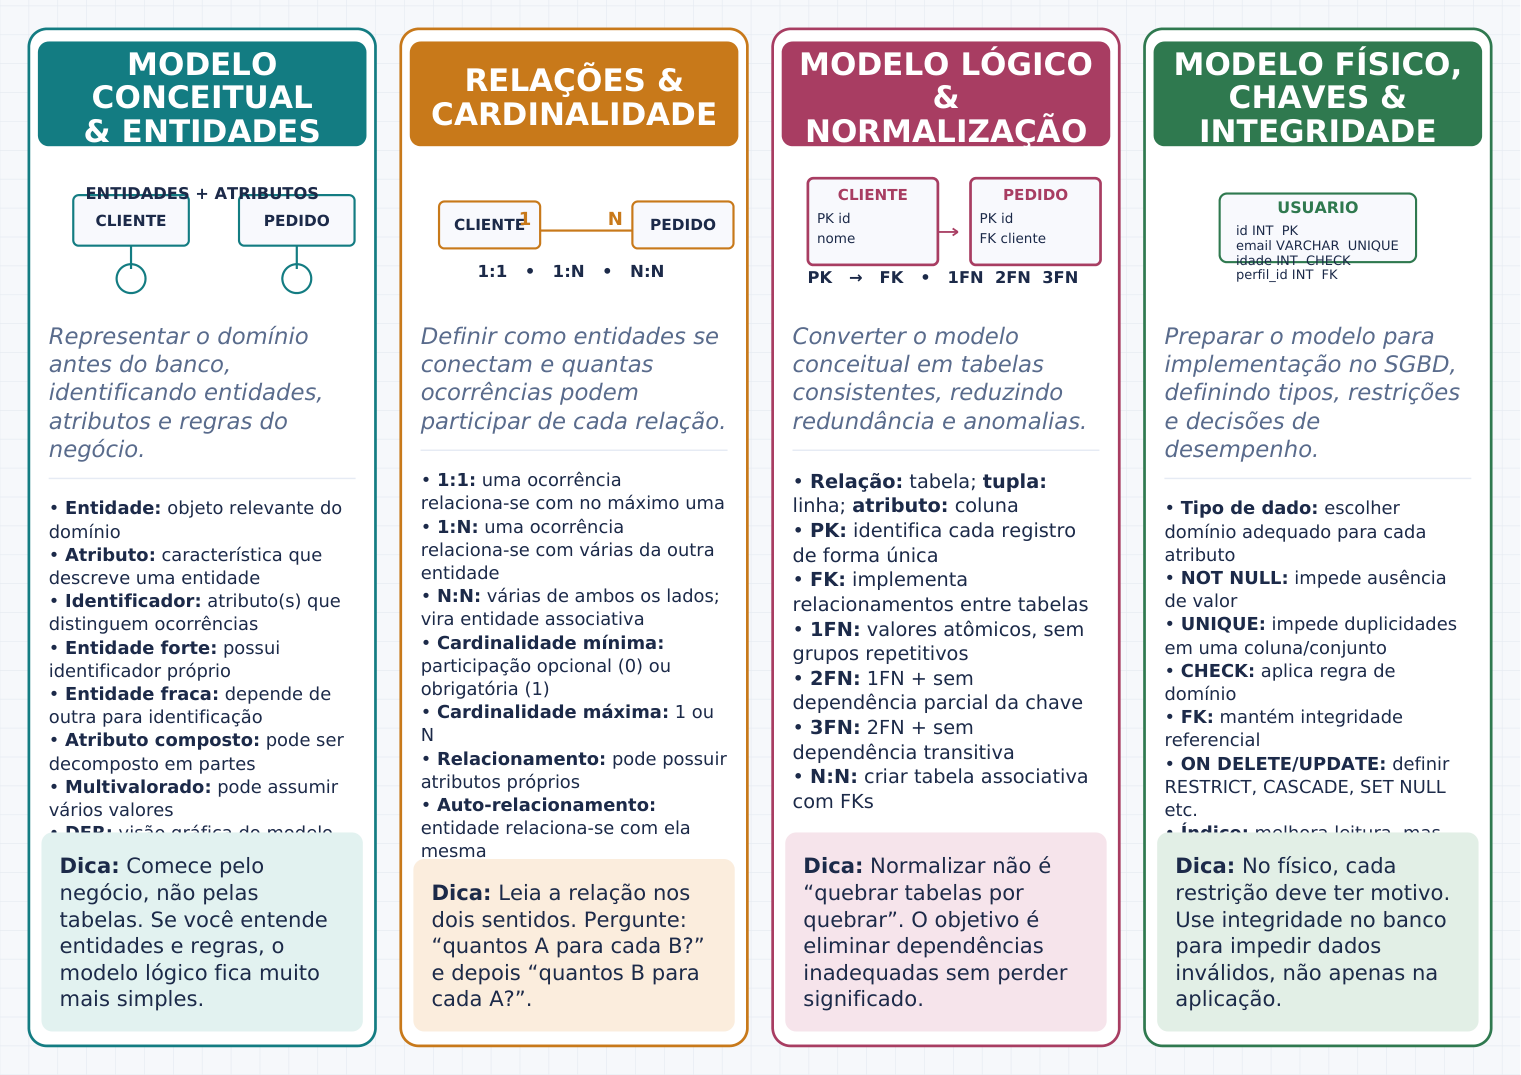

In [2]:
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Modelagem_de_Dados.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [3]:

import sqlite3

print("=" * 60)
print("1) MODELO CONCEITUAL (entidades e relacionamentos)")
entidades = ["ALUNO", "DISCIPLINA", "MATRICULA"]
relacoes = [("ALUNO", "MATRICULA", "1:N", "cursa"), ("DISCIPLINA", "MATRICULA", "1:N", "possui")]
for e1, e2, card, nome in relacoes:
    print(f"   {e1} {card} {nome} {e2}")

print("\n2) CARDINALIDADE - tipos")
print("   1:1  -> um para um (ex.: USUARIO - PASSAPORTE)")
print("   1:N  -> um para muitos (ex.: CLIENTE - PEDIDO)")
print("   N:M  -> muitos para muitos (ex.: ALUNO - DISCIPLINA via MATRICULA)")

print("\n3) NORMALIZACAO - tabela com problema (1FN)")
tabela = [("1", "Ana", "Mat1,Mat2"), ("2", "Bruno", "Mat3")]
print("   id | nome | disciplinas (viola 1FN: campo multivalorado)")

print("   Apos 1FN (atomo) + 2FN (sem dependencia parcial) + 3FN (sem transitiva):")
print("   ALUNO(id, nome)  |  MATRICULA(id_aluno, id_disc)  |  DISCIPLINA(id, nome)")

print("\n4) ESQUEMA FISICO com SQLite + consulta com JOIN")
con = sqlite3.connect(":memory:")
cur = con.cursor()
cur.executescript("""
CREATE TABLE aluno (id INTEGER PRIMARY KEY, nome TEXT);
CREATE TABLE disciplina (id INTEGER PRIMARY KEY, nome TEXT);
CREATE TABLE matricula (id_aluno INTEGER, id_disc INTEGER,
    FOREIGN KEY(id_aluno) REFERENCES aluno(id),
    FOREIGN KEY(id_disc) REFERENCES disciplina(id));
INSERT INTO aluno VALUES (1,'Ana'), (2,'Bruno'), (3,'Carla');
INSERT INTO disciplina VALUES (1,'BD'), (2,'Redes'), (3,'SO');
INSERT INTO matricula VALUES (1,1),(1,2),(2,2),(3,3);
""")
print("   Alunos matriculados em Redes:")
for linha in cur.execute("""
    SELECT a.nome, d.nome FROM aluno a
    JOIN matricula m ON m.id_aluno = a.id
    JOIN disciplina d ON d.id = m.id_disc
    WHERE d.nome = 'Redes'"""):
    print("   ", linha)

print("\n5) INTEGRIDADE REFERENCIAL - violacao de FK")
try:
    cur.execute("INSERT INTO matricula VALUES (99, 1)")   # aluno 99 nao existe
except sqlite3.IntegrityError as e:
    print(f"   bloqueado: {e}")

print("\n6) CONSULTA COM AGREGACAO")
print("   Matriculas por disciplina:")
for linha in cur.execute("""
    SELECT d.nome, COUNT(m.id_aluno) FROM disciplina d
    LEFT JOIN matricula m ON m.id_disc = d.id
    GROUP BY d.nome"""):
    print("   ", linha)
print("\nOK - modelagem e SQL demonstrados.")


1) MODELO CONCEITUAL (entidades e relacionamentos)
   ALUNO 1:N cursa MATRICULA
   DISCIPLINA 1:N possui MATRICULA

2) CARDINALIDADE - tipos
   1:1  -> um para um (ex.: USUARIO - PASSAPORTE)
   1:N  -> um para muitos (ex.: CLIENTE - PEDIDO)
   N:M  -> muitos para muitos (ex.: ALUNO - DISCIPLINA via MATRICULA)

3) NORMALIZACAO - tabela com problema (1FN)
   id | nome | disciplinas (viola 1FN: campo multivalorado)
   Apos 1FN (atomo) + 2FN (sem dependencia parcial) + 3FN (sem transitiva):
   ALUNO(id, nome)  |  MATRICULA(id_aluno, id_disc)  |  DISCIPLINA(id, nome)

4) ESQUEMA FISICO com SQLite + consulta com JOIN
   Alunos matriculados em Redes:
    ('Ana', 'Redes')
    ('Bruno', 'Redes')

5) INTEGRIDADE REFERENCIAL - violacao de FK

6) CONSULTA COM AGREGACAO
   Matriculas por disciplina:
    ('BD', 2)
    ('Redes', 2)
    ('SO', 1)

OK - modelagem e SQL demonstrados.


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
